# Agentic LangGraph Blog Writer Notebook

This notebook mirrors the production `app.py` workflow without the Streamlit UI. It accepts a text topic, routes the request, optionally researches with Tavily, plans the blog, generates an SVG visual asset, writes sections in parallel, and saves the final Markdown output.

Run the setup cells once, then change the topic in the final example cell.


## Setup

Create a `.env` file before running the notebook:

```text
OPENAI_API_KEY=your_openai_api_key_here
TAVILY_API_KEY=your_tavily_api_key_here
OPENAI_MODEL=gpt-4.1-mini
```


In [1]:
from __future__ import annotations

import hashlib
import html
import json
import operator
import os
import re
import textwrap
from pathlib import Path
from typing import TypedDict, List, Optional, Literal, Annotated

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv

# Fix SSL issue by removing invalid SSL_CERT_DIR and SSL_CERT_FILE if set
os.environ.pop("SSL_CERT_DIR", None)
os.environ.pop("SSL_CERT_FILE", None)

load_dotenv(dotenv_path=Path(".env"))

OUTPUT_DIR = Path("outputs")
ASSET_DIR = OUTPUT_DIR / "assets"
MODEL_NAME = os.getenv("OPENAI_MODEL", "gpt-4.1-mini")
IMAGE_BLOCK_START = "<!-- blog-images:start -->"
IMAGE_BLOCK_END = "<!-- blog-images:end -->"


c:\Users\mLc\anaconda3\envs\agentic_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# -----------------------------
# 1) Schemas
# -----------------------------
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=6,
        description="3-6 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(..., description="Target word count for this section (120-550).")

    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False


class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]


class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # keep if Tavily provides; DO NOT rely on it
    snippet: Optional[str] = None
    source: Optional[str] = None


class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str] = Field(default_factory=list)


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)


class VisualAssetSpec(BaseModel):
    title: str = Field(..., description="Short title for the generated visual asset.")
    subtitle: str = Field(..., description="One sentence explaining what the visual shows.")
    key_points: List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description="Three to five concise labels for the visual flow or infographic.",
    )
    callouts: List[str] = Field(
        default_factory=list,
        max_length=3,
        description="Optional short callouts to place below the visual.",
    )
    caption: str = Field(..., description="A polished caption for the blog.")
    alt_text: str = Field(..., description="Accessible alt text for the generated image.")


class GeneratedVisualAsset(BaseModel):
    saved_path: str
    markdown_path: str
    alt_text: str
    caption: str


class State(TypedDict):
    topic: str
    image_markdown: str
    visual_asset: Optional[GeneratedVisualAsset]

    # routing / research
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]

    # workers
    sections: Annotated[List[tuple[int, str]], operator.add]  # (task_id, section_md)
    final: str
    saved_file: str


def safe_markdown_filename(title: str) -> str:
    safe_name = re.sub(r'[<>:"/\\|?*\x00-\x1f]', "", title).strip()
    safe_name = re.sub(r"\s+", " ", safe_name)
    safe_name = safe_name.rstrip(". ")
    return f"{safe_name or 'generated_blog'}.md"


def safe_asset_stem(value: str) -> str:
    safe_name = re.sub(r"[^a-zA-Z0-9._-]+", "-", value).strip("-._")
    return safe_name[:70] or "blog-image"


def save_markdown_file(filename: str, contents: str) -> str:
    OUTPUT_DIR.mkdir(exist_ok=True)
    output_path = OUTPUT_DIR / filename
    output_path.write_text(contents, encoding="utf-8")
    return str(output_path)


def _svg_text_lines(text: str, width: int) -> List[str]:
    return textwrap.wrap(text.strip(), width=width) or [""]


def _svg_tspan(lines: List[str], x: int, y: int, size: int, color: str, weight: int = 500) -> str:
    escaped_lines = [html.escape(line) for line in lines]
    tspans = []
    for index, line in enumerate(escaped_lines):
        dy = 0 if index == 0 else int(size * 1.25)
        tspans.append(f'<tspan x="{x}" dy="{dy}">{line}</tspan>')
    return (
        f'<text x="{x}" y="{y}" fill="{color}" font-size="{size}" '
        f'font-family="Inter, Segoe UI, Arial, sans-serif" font-weight="{weight}">'
        f'{"".join(tspans)}</text>'
    )


def fallback_visual_spec(topic: str, plan: Optional[Plan]) -> VisualAssetSpec:
    task_titles = [task.title for task in (plan.tasks if plan else [])][:4]
    key_points = task_titles or [
        "Understand the core idea",
        "Map the implementation path",
        "Evaluate tradeoffs",
        "Apply practical next steps",
    ]

    return VisualAssetSpec(
        title=f"{topic}: visual overview",
        subtitle="A compact visual summary generated from the blog outline.",
        key_points=key_points[:5],
        callouts=["Planner", "Research", "Writer"],
        caption="Generated visual summary for the article.",
        alt_text=f"Infographic summarizing {topic}.",
    )


def render_visual_asset(topic: str, spec: VisualAssetSpec) -> GeneratedVisualAsset:
    ASSET_DIR.mkdir(parents=True, exist_ok=True)

    asset_payload = spec.model_dump()
    digest = hashlib.sha1(json.dumps(asset_payload, sort_keys=True).encode("utf-8")).hexdigest()[:10]
    filename = f"{safe_asset_stem(topic.lower())[:48]}-{digest}.svg"
    saved_path = ASSET_DIR / filename

    width = 1200
    height = 720
    card_y = 246
    card_h = 190
    margin = 72
    gap = 22
    points = spec.key_points[:5]
    card_w = int((width - (margin * 2) - (gap * (len(points) - 1))) / max(len(points), 1))
    palette = ["#5d7cff", "#26d6a4", "#f9c74f", "#f97068", "#9b5de5"]

    cards = []
    for index, point in enumerate(points):
        x = margin + index * (card_w + gap)
        color = palette[index % len(palette)]
        cards.append(
            f"""
            <g>
                <rect x="{x}" y="{card_y}" width="{card_w}" height="{card_h}" rx="18" fill="#141824" stroke="#2a3143" stroke-width="2"/>
                <circle cx="{x + 34}" cy="{card_y + 38}" r="18" fill="{color}"/>
                <text x="{x + 34}" y="{card_y + 45}" text-anchor="middle" fill="#07100d" font-size="18" font-family="Inter, Segoe UI, Arial, sans-serif" font-weight="800">{index + 1}</text>
                {_svg_tspan(_svg_text_lines(point, 18), x + 26, card_y + 92, 22, "#f4f6fb", 700)}
            </g>
            """
        )

    callout_text = " | ".join(spec.callouts[:3]) if spec.callouts else "Concept map | Key takeaways | Practical lens"

    svg = f"""<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}" role="img" aria-label="{html.escape(spec.alt_text)}">
    <rect width="{width}" height="{height}" fill="#07080c"/>
    <rect x="36" y="36" width="{width - 72}" height="{height - 72}" rx="28" fill="#0f1117" stroke="#252b3a" stroke-width="2"/>
    <rect x="72" y="72" width="230" height="46" rx="12" fill="#161b28" stroke="#2a3143"/>
    <text x="96" y="102" fill="#9aa3b2" font-size="17" font-family="Inter, Segoe UI, Arial, sans-serif" font-weight="700">GENERATED VISUAL</text>
    {_svg_tspan(_svg_text_lines(spec.title, 38), 72, 178, 42, "#f4f6fb", 800)}
    {_svg_tspan(_svg_text_lines(spec.subtitle, 86), 72, 210, 21, "#c7cedd", 500)}
    {"".join(cards)}
    <rect x="72" y="512" width="{width - 144}" height="82" rx="18" fill="#101722" stroke="#263044"/>
    <text x="100" y="562" fill="#26d6a4" font-size="22" font-family="Inter, Segoe UI, Arial, sans-serif" font-weight="800">Key lens</text>
    {_svg_tspan(_svg_text_lines(callout_text, 80), 220, 562, 22, "#f4f6fb", 600)}
    <text x="72" y="650" fill="#8e98aa" font-size="18" font-family="Inter, Segoe UI, Arial, sans-serif">{html.escape(spec.caption)}</text>
</svg>"""

    saved_path.write_text(svg, encoding="utf-8")

    return GeneratedVisualAsset(
        saved_path=str(saved_path),
        markdown_path=f"assets/{filename}",
        alt_text=spec.alt_text,
        caption=spec.caption,
    )


def build_image_markdown(asset: Optional[GeneratedVisualAsset]) -> str:
    if not asset:
        return ""

    blocks = [IMAGE_BLOCK_START, "## Visual References"]
    blocks.append(f"![{asset.alt_text}]({asset.markdown_path})\n\n*{asset.caption}*")
    blocks.append(IMAGE_BLOCK_END)
    return "\n\n".join(blocks)


def strip_image_markdown(markdown_text: str) -> str:
    pattern = rf"{re.escape(IMAGE_BLOCK_START)}.*?{re.escape(IMAGE_BLOCK_END)}\s*"
    return re.sub(pattern, "", markdown_text, flags=re.DOTALL).strip()


In [3]:
# -----------------------------
# 2) LLM
# -----------------------------
llm = ChatOpenAI(model=MODEL_NAME)


VISUAL_ASSET_SYSTEM = """You are a visual design agent for a technical blog generator.

Create a concise infographic plan that can be rendered as a graphical SVG image.

Rules:
- Base the visual only on the blog topic, outline, and provided evidence summary.
- Prefer a flow, lifecycle, comparison, or concept map that helps readers understand the article.
- Keep every label short enough to fit in a small card.
- Do not mention that the visual is AI-generated.
- Output must strictly match the VisualAssetSpec schema.
"""


In [4]:
# -----------------------------
# 3) Router (decide upfront)
# -----------------------------
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3-10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""

def router_node(state: State) -> dict:
    
    topic = state["topic"]
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}"),
        ]
    )

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
    }

def route_next(state: State) -> str:
    return "research" if state["needs_research"] else "orchestrator"


In [5]:
# -----------------------------
# 4) Research (Tavily) 
# -----------------------------
def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query": query})

    normalized: List[dict] = []
    for r in results or []:
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return normalized


RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state: State) -> dict:

    # take the first 10 queries from state
    queries = (state.get("queries", []) or [])
    max_results = 6

    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content=f"Raw results:\n{raw_results}"),
        ]
    )

    # Deduplicate by URL
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e

    return {"evidence": list(dedup.values())}


In [6]:
# -----------------------------
# 5) Orchestrator (Plan)
# -----------------------------
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5-9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3-6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120-550)

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book:
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient sources"
    and includes only what can be supported.
Output must strictly match the Plan schema.
"""

def orchestrator_node(state: State) -> dict:
    planner = llm.with_structured_output(Plan)

    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")

    plan = planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty):\n"
                    f"{[e.model_dump() for e in evidence][:16]}"
                )
            ),
        ]
    )

    return {"plan": plan}


In [7]:
# -----------------------------
# 6) Visual asset agent
# -----------------------------
def visual_asset_node(state: State) -> dict:
    plan = state["plan"]
    evidence = state.get("evidence", [])

    try:
        visual_designer = llm.with_structured_output(VisualAssetSpec)
        spec = visual_designer.invoke(
            [
                SystemMessage(content=VISUAL_ASSET_SYSTEM),
                HumanMessage(
                    content=(
                        f"Topic: {state['topic']}\n"
                        f"Blog title: {plan.blog_title}\n"
                        f"Audience: {plan.audience}\n"
                        f"Blog kind: {plan.blog_kind}\n\n"
                        f"Outline tasks:\n{[task.model_dump() for task in plan.tasks]}\n\n"
                        f"Evidence summary:\n{[item.model_dump() for item in evidence[:8]]}"
                    )
                ),
            ]
        )
    except Exception:
        spec = fallback_visual_spec(state["topic"], plan)

    asset = render_visual_asset(state["topic"], spec)
    image_markdown = build_image_markdown(asset)

    return {"visual_asset": asset, "image_markdown": image_markdown}


In [8]:
# -----------------------------
# 7) Fanout
# -----------------------------
def fanout(state: State):
    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
            },
        )
        for task in state["plan"].tasks
    ]


In [9]:
# -----------------------------
# 8) Worker (write one section)
# -----------------------------
WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (+/-15%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard:
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URLs.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true:
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""

def worker_node(payload: dict) -> dict:
    
    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]
    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )

    section_md = llm.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [(task.id, section_md)]}


In [10]:
# -----------------------------
# 9) Reducer (merge + save)
# -----------------------------
def reducer_node(state: State) -> dict:

    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    image_markdown = state.get("image_markdown", "").strip()
    parts = [f"# {plan.blog_title}", image_markdown, body]
    final_md = "\n\n".join(part for part in parts if part).strip() + "\n"

    filename = safe_markdown_filename(plan.blog_title)
    saved_file = save_markdown_file(filename, final_md)

    return {"final": final_md, "saved_file": saved_file}


In [11]:
# -----------------------------
# 10) Build graph
# -----------------------------
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("visual_asset", visual_asset_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_edge("orchestrator", "visual_asset")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("visual_asset", "reducer")
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app_graph = g.compile()


In [12]:
# -----------------------------
# 11) Runner
# -----------------------------
def run(topic: str):
    out = app_graph.invoke(
        {
            "topic": topic,
            "image_markdown": "",
            "visual_asset": None,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
            "saved_file": "",
        }
    )

    return out


## Run the blog generator

This cell generates the Markdown blog and the SVG visual asset.


In [13]:
# Change this topic and run the cell.
topic = "State of Multimodal LLMs in 2026"

result = run(topic)

print(f"Saved blog: {result['saved_file']}")
visual_asset = result.get("visual_asset")
if visual_asset:
    print(f"Generated visual: {visual_asset.saved_path}")

result["final"][:1500]


C:\Users\mLc\AppData\Local\Temp\ipykernel_14240\4168389408.py:6: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=max_results)


Saved blog: outputs\State of Multimodal LLMs in 2026.md
Generated visual: outputs\assets\state-of-multimodal-llms-in-2026-2ec514e4df.svg


'# State of Multimodal LLMs in 2026\n\n<!-- blog-images:start -->\n\n## Visual References\n\n![Infographic showing the state of multimodal large language models in 2026. The visual highlights leading models like GPT-4o and Gemini 2.5 Pro, core technology trends such as fusion modules and large context windows, innovations like sparse mixture-of-experts, major application areas including healthcare and retail, and notable challenges including data annotation and modality alignment.](assets/state-of-multimodal-llms-in-2026-2ec514e4df.svg)\n\n*This infographic maps the landscape and evolution of multimodal large language models in 2026, highlighting leading models, innovative architectures, impactful industry applications, and the challenges they face. It showcases critical technological advancements and emerging trends shaping the future of AI powered by multimodal data integration.*\n\n<!-- blog-images:end -->\n\n## Overview of the Multimodal LLM Landscape in 2026\n\nIn 2026, the multim

## Preview output

Render the generated Markdown and SVG inside the notebook.


# State of Multimodal LLMs in 2026

<!-- blog-images:start -->

## Visual References

![Infographic showing the state of multimodal large language models in 2026. The visual highlights leading models like GPT-4o and Gemini 2.5 Pro, core technology trends such as fusion modules and large context windows, innovations like sparse mixture-of-experts, major application areas including healthcare and retail, and notable challenges including data annotation and modality alignment.](assets/state-of-multimodal-llms-in-2026-2ec514e4df.svg)

*This infographic maps the landscape and evolution of multimodal large language models in 2026, highlighting leading models, innovative architectures, impactful industry applications, and the challenges they face. It showcases critical technological advancements and emerging trends shaping the future of AI powered by multimodal data integration.*

<!-- blog-images:end -->

## Overview of the Multimodal LLM Landscape in 2026

In 2026, the multimodal large language model (LLM) ecosystem has matured into a diverse and highly capable landscape. Leading proprietary models such as OpenAI’s GPT-4o, Google’s Gemini 2.5 Pro, and Anthropic’s Claude dominate the field by seamlessly integrating multiple data modalities to enhance understanding and generation across diverse formats ([SiliconFlow](https://www.siliconflow.com/articles/en/best-multimodal-ai-models), [Ideas2IT](https://www.ideas2it.com/blogs/llm-comparison)).

### Key Multimodal Models

- **OpenAI’s GPT-4o** extends the GPT-4 architecture with strengthened multimodal capabilities, supporting text, images, and audio inputs to enable richer interactive experiences.
- **Google’s Gemini 2.5 Pro** pushes the envelope with advanced video and speech processing integrated alongside text and images, targeting complex real-world applications.
- **Anthropic’s Claude** emphasizes ethical AI and robustness while maintaining strong multimodal proficiency, particularly in combining language with visual contexts.

These models reflect the trend toward hybrid AI systems capable of ingesting and reasoning over heterogeneous data types for a unified response.

### Supported Modalities and Integration

The most common modalities handled by these multimodal LLMs include:

- Text (natural language input and output)
- Visual data (images, diagrams, and increasingly video)
- Audio (speech recognition and synthesis, sound event recognition)
- Structured data (tables and metadata)

Integration approaches typically employ modality-specific encoders feeding into a shared semantic latent space, enabling cross-modal attention and fusion. This allows the model to align concepts across modalities and generate coherent multimodal outputs ([TileDB](https://www.tiledb.com/blog/multimodal-ai-models), [Clarifai](https://www.clarifai.com/blog/llms-and-ai-trends)).

### Architectural Evolution

To enable such extensive multimodality, architectures have evolved to include:

- **Mixture-of-experts (MoE)** layers that dynamically activate specialized subnetworks for different modalities or tasks, improving scalability and performance.
- **Fusion modules** that integrate encoded features from each modality before decoding or downstream reasoning, allowing tight coupling of information.
- Expanded transformer layers with cross-attention mechanisms designed specifically for modality alignment.

These innovations greatly enhance the models’ ability to learn complex correlations and provide more contextually relevant outputs ([UnitLab](https://blog.unitlab.ai/top-multimodal-models), [Encord](https://encord.com/blog/top-multimodal-models)).

### Industry and Research Impact

Multimodal AI is increasingly critical across industries such as healthcare (medical image and report synthesis), autonomous driving (video and sensor fusion), and content creation (combining text, visuals, and audio). In research, these models accelerate progress in human-computer interaction, multimodal understanding, and multimodal generation tasks ([USAII](https://www.usaii.org/ai-insights/how-multimodal-ai-is-redefining-modern-ai-applications)).

### Expanding Context Windows

One notable advancement in 2026 is the dramatic increase in context window sizes. Some models support up to one million tokens of unified cross-modal context, enabling extended conversations and detailed multi-source input reasoning within a single model instance. This expansion provides the foundation for more nuanced understanding and long-term coherence across modalities ([Clarifai](https://www.clarifai.com/blog/llms-and-ai-trends)).

### Towards Real-Time and Unified Agents

There is accelerating momentum toward real-time multimodal applications. This includes unified agent platforms capable of processing live audio, video, and text streams simultaneously to act in dynamic environments. This shift paves the way for interactive assistants, immersive AR/VR experiences, and sophisticated decision support systems that operate seamlessly across modalities ([InvisibleTech](https://invisibletech.ai/2026-trends/multimodal)).

---

Overall, 2026 marks a pivotal year where multimodal LLMs not only advance in technical sophistication but also proliferate across practical deployments, setting the stage for a new era of AI-human collaboration through richer, multimodal communication channels.

## Top Multimodal LLMs and Their Innovations in 2026

The landscape of multimodal large language models (LLMs) in 2026 features a range of standout models pushing the frontier in architecture, efficiency, and multimodal understanding. Key players include GLM-4.5V, GLM-4.1V-9B-Thinking, Qwen2.5-VL-32B-Instruct, Gemini 2.5 Pro, and GPT-4o, each bringing distinct innovations to the table.

### Architecture Innovations

Among these models, sparse mixture-of-experts (MoE) architectures have gained traction to boost scalability and efficiency without linearly increasing computational cost. For instance, GPT-4o employs an MoE design that enables it to scale to billions of parameters while maintaining manageable inference latency. GLM-4.5V and Gemini 2.5 Pro extend context windows significantly beyond previous generations, allowing them to process longer multimodal inputs, such as lengthy documents with embedded images or video frames. This extended context facilitates more coherent dialogue and complex reasoning over multimodal data ([Source](https://www.siliconflow.com/articles/en/best-multimodal-ai-models)).

### Speed and Efficiency

Benchmarking in 2026 indicates notable improvements in throughput and latency. Qwen2.5-VL-32B-Instruct, a 32-billion-parameter model, achieves competitive inference speeds by leveraging optimized kernel implementations and hardware-aware model pruning. Comparatively, GLM-4.1V-9B-Thinking focuses on efficiency, targeting edge deployment scenarios, and achieves high responsiveness through lightweight model design and instruction tuning ([Source](https://www.siliconflow.com/articles/en/fastest-open-source-multimodal-models)).

### Multimodal Capabilities

A defining feature of these top multimodal LLMs is their ability to process and integrate multiple data modalities simultaneously:

- **Text & Images:** All mentioned models robustly understand and generate text grounded in visual contexts, enabling applications such as image captioning, visual question answering, and document analysis.
- **Video:** Gemini 2.5 Pro and GPT-4o extend support to video inputs, allowing temporal reasoning over sequences of frames, critical for tasks like video summarization or action recognition.
- **Audio:** Qwen2.5-VL-32B-Instruct incorporates audio modalities, enabling complex speech understanding combined with visual and textual information, a feature increasingly important for interactive AI agents ([Source](https://www.tiledb.com/blog/multimodal-ai-models)).

### Instruction Tuning and Agent Readiness

A major advancement in 2026 is the improved instruction tuning focused on complex multimodal task handling and agent readiness. Models like GLM-4.1V-9B-Thinking and GPT-4o have been fine-tuned with multimodal instructions, enabling them to follow nuanced user intents across data types and integrate external knowledge sources dynamically. This makes these models suitable for real-world interactive scenarios, such as personal assistants or creative AI collaborators ([Source](https://www.clarifai.com/blog/llms-and-ai-trends)).

### Open-Source vs Proprietary and Community Adoption

The ecosystem shows a blend of proprietary and open-source models:

- **Open-Source:** GLM-4.1V-9B-Thinking and Qwen2.5-VL-32B-Instruct have open-source variants or accessible APIs, fostering community adoption and enabling customization for domain-specific applications.
- **Proprietary:** Gemini 2.5 Pro and GPT-4o remain largely proprietary, emphasizing enterprise-grade support, compliance, and integration with extensive cloud services.

Community enthusiasm tends to favor open models for research and innovation, while proprietary options dominate production environments that require robust SLAs and end-to-end solutions ([Source](https://blog.unitlab.ai/top-multimodal-models)).

### Summary

In 2026, the top multimodal LLMs differentiate themselves through advanced sparse architectures, extended context processing, efficient design, and rich multimodal input capabilities covering text, vision, video, and audio. Instruction tuning has matured to enable agent-level autonomy in multimodal tasks, while the diversity of open-source and proprietary models offers choices balancing innovation and reliability. This dynamic fuels rapid integration of multimodal LLMs in increasingly complex AI applications—from content creation and real-time analysis to cross-modal reasoning and intelligent assistance.

[Source References](https://www.siliconflow.com/articles/en/best-multimodal-ai-models) | [Open Source Models Benchmark](https://www.siliconflow.com/articles/en/fastest-open-source-multimodal-models) | [Multimodal AI Innovation](https://www.tiledb.com/blog/multimodal-ai-models) | [AI Trends 2026](https://www.clarifai.com/blog/llms-and-ai-trends) | [Community Adoption Overview](https://blog.unitlab.ai/top-multimodal-models)

## Key Technological Trends Driving Multimodal LLMs in 2026

The rapid evolution of multimodal large language models (LLMs) in 2026 is shaped by a confluence of architectural innovations, scaling breakthroughs, and deployment advances that collectively enhance AI's ability to process and reason across diverse data types.

### Advances in Architectural Design: Fusion Modules and Sparse Mixture-of-Experts

One of the pivotal trends is the refinement of architectural components tailored to optimize multimodal reasoning. Fusion modules—specialized layers that synergistically combine modalities such as text, images, and audio—have become more sophisticated, enabling models to learn intricate cross-modal relationships effectively. Complementing this, the widespread adoption of sparse mixture-of-experts (MoE) architectures optimizes model capacity by dynamically activating only relevant expert subnetworks during inference. This selective pathway routing not only reduces computational overhead but also enhances multimodal contextual understanding, making models more efficient and scalable ([Source](https://www.siliconflow.com/articles/en/best-multimodal-ai-models)).

### Extreme Context Window Scaling and Its Impact

Context window size has been a traditional constraint in LLM applications. In 2026, models now routinely support context windows scaling up to 1 million tokens, a transformative leap enabling persistent and coherent multi-hour interactions, long-document understanding, and complex sequence modeling. This extreme scaling facilitates new use cases including comprehensive video analysis transcripts, legal and scientific document aggregation, and extended conversational agents that maintain nuanced context over lengthy dialogues ([Source](https://www.clarifai.com/blog/llms-and-ai-trends)).

### Integration of Real-Time Data Access Systems

Dynamic multimodal interactions are further empowered by models integrating real-time data access. Rather than relying solely on static pretrained representations, these LLMs interface with external knowledge bases, APIs, and sensor inputs to retrieve, update, and contextualize information on the fly. This capability allows for live adaptation to events, continuous learning, and enhanced situational awareness in applications such as autonomous driving, live content summarization, and interactive gaming agents ([Source](https://www.tiledb.com/blog/multimodal-ai-models)).

### Rise of Natively Multimodal Agents and Chatbots

Another notable trend is the emergence of natively multimodal agents and chatbots, exemplified by recent Gemini 3 and ChatGPT-5 launches. These systems are designed from the ground up to fluently process and generate across modalities—text, images, audio, and video—enabling richer, more intuitive human-AI interaction experiences. Such agents integrate multimodal understanding with task-specific capabilities, providing unified interfaces for creative work, data analysis, and personalized communication ([Source](https://www.ideas2it.com/blogs/llm-comparison)).

### New Deployment and Model Compression Techniques

Efficient deployment remains a critical challenge for multimodal models, given their large parameter counts and heterogeneous input formats. Advances in model compression—including use of knowledge distillation, quantization, and pruning tailored for multimodal layers—have reduced resource demands without sacrificing accuracy. Coupled with edge deployment frameworks and scalable serving infrastructures, these innovations make it feasible to integrate complex multimodal LLMs into mobile and embedded devices, expanding the reach of AI applications ([Source](https://www.bentoml.com/blog/multimodal-ai-a-guide-to-open-source-vision-language-models)).

### Growth in Open-Source Multimodal LLM Projects

Finally, the open-source ecosystem for multimodal LLMs has seen accelerated growth, driving community-driven innovation and accessibility. Projects such as those cataloged at SiliconFlow and BentoML showcase a variety of high-performance, customizable models covering diverse domains and modalities. This surge in open-source contributions fuels experimentation, benchmarking, and rapid iteration, fostering an ecosystem that complements proprietary efforts and broadens adoption across industries ([Source](https://www.siliconflow.com/articles/en/best-open-source-multimodal-models-2025)).

---

Collectively, these technological trends underline a paradigm shift in multimodal AI: toward more capable, context-aware, and accessible models that empower developers to build sophisticated applications bridging multiple modalities seamlessly.

## Multimodal LLM Applications Transforming Industries in 2026

Multimodal large language models (LLMs) have become pivotal in advancing AI applications across diverse industries in 2026. By integrating different data types—such as text, images, audio, and structured data—these models offer richer insights and more nuanced understanding, driving innovation in practical use cases.

### Healthcare: Diagnostic Imaging Meets Patient Records

In healthcare, multimodal LLMs combine diagnostic imaging with electronic health records to enhance diagnostic accuracy and personalized treatment plans. Models are capable of jointly analyzing radiology images alongside textual patient histories, lab results, and clinical notes. This fusion helps clinicians detect subtle patterns, predict disease progression, and generate comprehensive reports automatically. The capability to cross-reference multiple modalities accelerates clinical decision-making and improves patient outcomes ([Source](https://www.usaii.org/ai-insights/how-multimodal-ai-is-redefining-modern-ai-applications)).

### Retail: Unified Content Creation Enhances Customer Experience

Retailers leverage multimodal LLMs to unify text and image inputs for content creation, boosting marketing and customer engagement efforts. These models generate product descriptions paired with optimized visuals, social media posts, and even personalized promotional material all in one workflow. The seamless integration of modalities supports dynamic catalog updates and immersive shopping experiences, fostering higher customer satisfaction and conversion rates ([Source](https://www.siliconflow.com/articles/en/best-multimodal-ai-models)).

### Digital Platforms and Social Media: Moderation and Accessibility

Digital platforms increasingly deploy multimodal LLMs to improve content moderation by understanding the context of images, videos, and captions together. This holistic approach enables more accurate detection of inappropriate content, misinformation, or harmful behavior. Furthermore, these models enhance content accessibility by generating alt text for images and video captions, improving inclusivity for users with disabilities ([Source](https://www.clarifai.com/blog/llms-and-ai-trends)).

### Industry Sensing and Enterprise Adoption: Unifying Diverse Data Streams

Enterprises adopt multimodal LLMs to unify and analyze complex, heterogeneous data streams including text documents, audio recordings, video footage, and structured databases. This unified data interpretation capability supports advanced analytics scenarios such as predictive maintenance, customer sentiment analysis, and operational intelligence. By consolidating multiple modalities into coherent knowledge graphs and dashboards, companies better identify trends and optimize decision-making processes ([Source](https://www.tiledb.com/blog/multimodal-ai-models)).

### Challenges: Data Annotation Complexity and Solutions

Despite their potential, multimodal LLMs face challenges due to the complexity of annotating diverse and large-scale multimodal datasets. Labeling images, videos, audio, and text in a synchronized manner is labor-intensive and requires domain expertise. To address this, industries are investing in semi-automated annotation tools powered by active learning frameworks and crowdsourcing platforms. These tools accelerate data preparation while maintaining quality, supporting scalable model training and refinement ([Source](https://encord.com/blog/top-multimodal-models)).

### Enhancing Research Workflows with Integrated Modal Queries

In research, multimodal LLMs facilitate workflows by integrating diverse data modalities into unified queries and summaries. Researchers can input mixed media—such as charts, images, and text descriptions—and receive synthesized insights or literature overviews. This capability streamlines data exploration, hypothesis generation, and cross-disciplinary collaboration, ultimately advancing scientific discovery more efficiently ([Source](https://blog.bytebytego.com/p/whats-next-in-ai-five-trends-to-watch)).

Overall, multimodal LLMs in 2026 are reshaping industries by enabling richer, more contextual AI-driven capabilities. While challenges like annotation complexity persist, continued technological progress and innovation in deployment practices are unlocking transformative applications worldwide.

## Performance, Speed, and Efficiency Highlights of Multimodal LLMs in 2026

In 2026, the landscape of multimodal large language models (LLMs) is marked by significant advances in inference speed, efficiency, and deployment scalability. Leading models such as GLM-4.1V-9B-Thinking, Qwen2.5-VL-32B-Instruct, and GLM-4.5V have emerged as top contenders in benchmarks that measure real-world performance for diverse multimodal tasks.

### Benchmark Comparisons of Inference Speed

Recent benchmark results indicate that GLM-4.1V-9B-Thinking excels in inference speed due to its relatively compact architecture and optimized fusion of vision and language modalities. Meanwhile, Qwen2.5-VL-32B-Instruct, despite its larger parameter count, showcases competitive latency performance owing to efficient parallelization. GLM-4.5V strikes a balance with moderate model size and fast multimodal reasoning, making it a versatile choice for many applications ([SiliconFlow](https://www.siliconflow.com/articles/en/fastest-open-source-multimodal-models), [Encord](https://encord.com/blog/top-multimodal-models)).

### Architectural Features Driving Speed

Key to the advancements in speed are architectural innovations such as mixture-of-experts (MoE) layers, which dynamically activate subsets of model parameters based on input context, reducing computational overhead. Efficient fusion mechanisms that integrate visual and linguistic information earlier in the model pipeline also contribute to lower latency. These methods optimize resource use without sacrificing the granularity of multimodal interactions ([Unit Lab](https://blog.unitlab.ai/top-multimodal-models), [Clarifai](https://www.clarifai.com/blog/llms-and-ai-trends)).

### Trade-offs Between Model Size, Speed, and Accuracy

Studies reveal a nuanced trade-off: larger models like Qwen2.5-VL-32B-Instruct achieve higher multimodal accuracy but at the expense of slower inference and higher resource consumption. Conversely, smaller models such as GLM-4.1V-9B-Thinking offer faster responses but may slightly underperform on complex multimodal benchmarks. This spectrum allows practitioners to select models aligned with their accuracy-speed requirements and infrastructure constraints ([Pluralsight](https://www.pluralsight.com/resources/blog/ai-and-data/best-ai-models-2026-list), [SiliconFlow](https://www.siliconflow.com/articles/en/best-multimodal-ai-models)).

### Advances in Deployment and Compression Techniques

Deployment innovations have further enhanced cost-efficiency and scalability. Techniques like quantization, pruning, and knowledge distillation are now routinely applied to compress large multimodal models without dramatic accuracy loss. Cloud-native serving architectures support elastic scaling, ensuring responsiveness in diverse workload scenarios. Together, these advances bring powerful multimodal LLMs within reach for enterprises with limited infrastructure budgets ([BentoML](https://www.bentoml.com/blog/multimodal-ai-a-guide-to-open-source-vision-language-models), [Invisible Technologies](https://invisibletech.ai/2026-trends/multimodal)).

### Implications for Real-Time Multimodal Applications

The reduction in latency and improvement in scalability have critical implications for deploying multimodal LLMs in real-time or near-real-time applications such as interactive AI assistants, augmented reality, and automated content moderation. Lower response times enhance user experience and enable smooth integration of language and vision modalities in dynamic settings, driving wider adoption in production environments ([USAIi](https://www.usaii.org/ai-insights/how-multimodal-ai-is-redefining-modern-ai-applications)).

### Latency and Scalability as Enterprise Metrics

For enterprises, latency and scalability remain the most vital metrics when selecting multimodal LLMs. Models that efficiently balance speed and accuracy reduce operational costs and provide the flexibility to handle fluctuating demand. The evolving capabilities of the current generation focus heavily on these factors, ensuring that AI-powered multimodal workflows can be deployed at scale without compromising performance ([Whistler Billboards](https://www.whistlerbillboards.com/friday-feature/top-llms-2026), [Ideas2IT](https://www.ideas2it.com/blogs/llm-comparison)).

In summary, 2026’s multimodal LLMs demonstrate a maturing ecosystem where architectural and deployment innovations drive significant gains in speed and efficiency. These improvements empower developers and enterprises to build responsive, scalable, and accurate multimodal AI applications suitable for real-world challenges.

## Challenges and Limitations of Multimodal LLMs in 2026

Multimodal large language models (LLMs) in 2026 have pushed the boundaries of AI by integrating text, images, audio, and other data types. However, their complexity introduces several persistent challenges and limitations that developers encounter today.

### Complexity in Multimodal Data Annotation

One of the foundational challenges lies in the annotation of multimodal data. Unlike unimodal datasets, multimodal datasets require synchronized and accurate labeling across diverse data types, which is labor-intensive and error-prone. This complexity directly impacts the quality and diversity of training data, often limiting the generalization capabilities of models. The scarcity of high-quality, well-annotated multimodal datasets leads to imbalanced learning and hinders performance across underrepresented modalities ([Source](https://www.siliconflow.com/articles/en/best-multimodal-ai-models)).

### Model Limitations: Modality Alignment and Imbalance

Multimodal LLMs struggle with modality alignment errors, where semantics or context from one modality fail to correctly correlate with another. This issue causes degraded understanding and irrelevant or contradictory outputs. Additionally, performance degrades significantly when modalities are imbalanced—for instance, when one modality provides richer cues than others or some inputs are missing or noisy. These discrepancies lead to lowered accuracy and confidence in decision-making processes ([Source](https://encord.com/blog/top-multimodal-models)).

### Scalability Challenges

Scaling multimodal models by increasing the number of modalities alongside expanding the context window size introduces computational and architectural difficulties. As model capacity and input complexity rise, training and inference become resource-intensive. Maintaining efficient cross-modal attention mechanisms and balancing contextual understanding without overfitting or latency issues remains a significant hurdle. These scalability issues affect deployment feasibility in resource-constrained environments ([Source](https://www.tiledb.com/blog/multimodal-ai-models)).

### Debugging and Interpretability Difficulties

Interpreting decisions within multimodal reasoning pipelines is inherently difficult. The fusion of heterogeneous data streams complicates tracing errors back to specific input modalities or model components. Developers face challenges in debugging because model outputs may be driven by subtle interactions among modalities, which are not easily explainable. This opacity restricts trust and limits the models’ adoption in critical applications requiring transparency ([Source](https://invisibletech.ai/2026-trends/multimodal)).

### Privacy and Security Concerns

Combining multiple data modalities amplifies privacy and security risks. Sensitive information from different modalities can unintentionally be revealed or leaked during processing or storage, heightening concerns for applications handling personal or confidential data. Moreover, multimodal fusion complicates applying uniform data protection policies and secure model auditing. Ensuring compliance with privacy regulations while delivering rich multimodal insights remains an ongoing challenge ([Source](https://www.clarifai.com/blog/llms-and-ai-trends)).

### Robustness to Noisy or Incomplete Inputs

Real-world multimodal inputs often suffer from noise, distortions, or missing data fields. Robustness of multimodal LLMs to these imperfections is limited, resulting in unstable or incorrect predictions. Handling partial modality failure gracefully—such as blurry images, unclear audio, or truncated text—without compromising downstream tasks is an active research focus but remains challenging in production scenarios ([Source](https://www.usaii.org/ai-insights/how-multimodal-ai-is-redefining-modern-ai-applications)).

In summary, while multimodal LLMs are transforming AI capabilities in 2026, their effectiveness is tempered by complexity in annotation, modality alignment and balance, scalability, interpretability, privacy, and real-world robustness. Addressing these challenges is crucial for broader adoption and reliable deployment in diverse, multimodal environments.

## Future Outlook: What to Expect Next in Multimodal LLM Development

Looking beyond 2026, multimodal large language models (LLMs) are poised to evolve dramatically, integrating richer data types and expanding their capabilities in autonomous reasoning, community collaboration, and deployment efficiency.

- **Advancements in Model Unification Across Modalities**  
  Future multimodal LLMs will move beyond combining text and images to seamlessly incorporate structured data, 3D inputs, and even sensory signals like audio, touch, and environmental data. This unification will enable models to understand and interact with the world more holistically, opening new frontiers in robotics, augmented reality, and scientific research where multi-sensor fusion is critical ([Source](https://www.siliconflow.com/articles/en/best-multimodal-ai-models)).

- **Rise of Fully Autonomous Multimodal AI Agents**  
  We can anticipate the emergence of AI agents capable of autonomously interpreting complex multimodal inputs, reasoning through scenarios, and planning long-term actions without human intervention. These agents will leverage enhanced contextual understanding spanning multiple data types, improving decision-making in dynamic real-world environments such as autonomous vehicles, personalized healthcare, and smart manufacturing ([Source](https://www.clarifai.com/blog/llms-and-ai-trends)).

- **Growth in Open-Weight and Community-Driven Models**  
  Transparency and fairness in AI will be increasingly supported by the trend towards open-weight models and collaborative community contributions. Such models promote reproducibility, reduce bias, and democratize access to cutting-edge multimodal capabilities. This development is expected to accelerate innovation through open benchmarking, shared datasets, and inclusive model governance ([Source](https://www.bentoml.com/blog/multimodal-ai-a-guide-to-open-source-vision-language-models)).

- **Hardware and Software Co-Design for Performance**  
  Multimodal inference demands more efficient compute and memory architectures. Therefore, co-design approaches integrating specialized AI accelerators with optimized software frameworks will be crucial. These innovations will enhance scalability and reduce latency, enabling real-time multimodal processing on edge devices and large-scale systems alike ([Source](https://invisibletech.ai/2026-trends/multimodal)).

- **Natural Language Interfaces Enabling Collaborative Multimodal Dialogues**  
  The next generation of interfaces will blend natural language with multimodal input/output for richer, more intuitive AI interactions. Users will collaborate with AI seamlessly across text, voice, images, and video, facilitating complex workflows in creative industries, education, and enterprise applications. This capability will unlock more dynamic, context-aware conversations and cooperative problem solving ([Source](https://www.tiledb.com/blog/multimodal-ai-models)).

- **Evolving Ethical and Regulatory Challenges**  
  As multimodal AI pervades sensitive domains, new ethical and legal frameworks will be needed to address privacy, bias, and liability concerns. Standardization efforts are expected to emerge for data usage, model evaluation, and transparency practices, balancing innovation with responsible AI deployment. Stakeholders will need to engage early with these evolving landscapes to ensure trust and compliance ([Source](https://www.usaii.org/ai-insights/how-multimodal-ai-is-redefining-modern-ai-applications)).

Overall, the post-2026 horizon for multimodal LLMs promises more unified, autonomous, transparent, and efficient AI systems complemented by a growing emphasis on ethical governance and human-AI collaboration. Staying abreast of these directions will be essential for developers and practitioners driving the next wave of AI innovation.


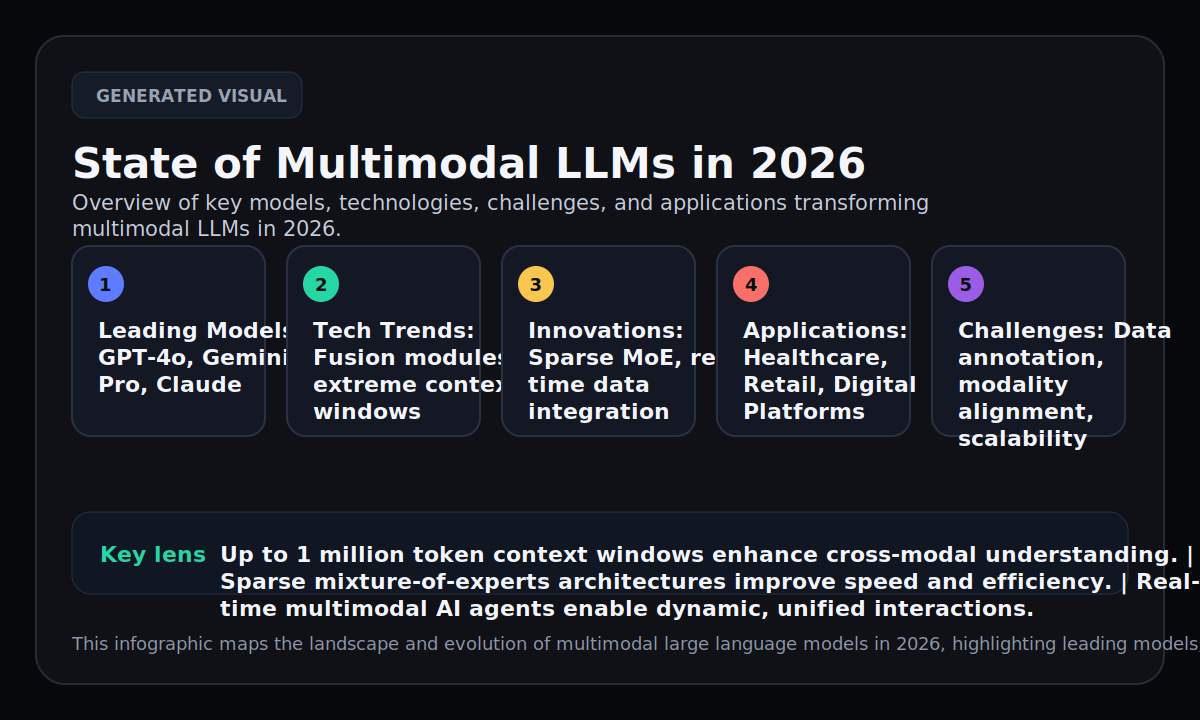

In [14]:
from IPython.display import Markdown, SVG, display

display(Markdown(result["final"]))
visual_asset = result.get("visual_asset")
if visual_asset:
    display(SVG(filename=visual_asset.saved_path))
